
# Proyecto Final
A continuación, se utilizarán Python y las bibliotecas de análisis de datos pertinentes para responder las siguientes preguntas de investigación:<br/><br/>

**Análisis Exploratorio**

1.   ¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal a partir de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?
2.   ¿Qué grupos de municipios presentan patrones o comportamientos similares, mediante técnicas de clustering, respecto a la rapidez con la que se resuelven los casos, considerando la tasa de localización con vida frente a la tasa de no localización?
3.   ¿Existe alguna relación o patrón estacional entre los meses del año, como periodos vacacionales o trimestres específicos, y los incrementos repentinos en el número de registros?
<br/>

**Análisis Descriptivo**


1.   ¿Cuáles son los cinco estados con el mayor número acumulado de registros?
2.   ¿Qué proporción del total de casos corresponde a personas localizadas con vida, localizadas sin vida y personas que permanecen con estatus de no localizadas?

**Primer paso.**

Se incorporará acceso a Google Drive, el cual será utilizado como repositorio central para el almacenamiento y la gestión de los datos del proyecto.

Esto permitirá contar con una ubicación centralizada para la información, facilitando el acceso, la colaboración y la administración de los conjuntos de datos que serán utilizados durante el análisis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Segundo Paso**

Se importan las bibliotecas necesarias para el análisis y se carga un archivo consolidado que integra los cuatro conjuntos de datos obtenidos. En caso de ser necesario, la información será filtrada utilizando el campo status_id, dependiendo de los requerimientos específicos de cada análisis.

Este enfoque permite trabajar sobre una fuente de datos unificada, facilitando la exploración, transformación y análisis de la información de manera consistente a lo largo del proyecto.

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv('/content/drive/MyDrive/MIAAD/202602-AnaliticaDescriptivaPredictiva/Proyecto/Datos/all_desappiarences.csv')
df


,cvegeo,cve_estado,state,cve_mun,municipality,male,female,undefined,total,year,month,status_id
0,1001,1,aguascalientes,1,aguascalientes,19,21,0,40,2015,1,0
1,1001,1,aguascalientes,1,aguascalientes,7,14,0,21,2015,2,0
2,1001,1,aguascalientes,1,aguascalientes,12,23,0,35,2015,3,0
3,1001,1,aguascalientes,1,aguascalientes,17,28,0,45,2015,4,0
4,1001,1,aguascalientes,1,aguascalientes,11,24,0,35,2015,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...
139300,32999,32,zacatecas,999,se desconoce,1,0,0,1,2024,1,3
139301,99998,99,unknown,999,se desconoce,0,1,0,1,2019,9,3
139302,99998,99,unknown,999,se desconoce,1,0,0,1,2019,10,3
139303,99998,99,unknown,999,se desconoce,0,1,0,1,2019,11,3


**Tercer Paso**

Se realiza un conteo de los registros cargados en el DataFrame con el objetivo de validar el volumen de información importada. Posteriormente, se verificará la existencia de registros duplicados para garantizar la calidad de los datos antes de continuar con las etapas de limpieza, transformación y procesamiento.

Esta validación inicial permite asegurar la integridad del conjunto de datos y reducir posibles inconsistencias que pudieran afectar los resultados del análisis.

In [57]:
totalRecords = len(df)
print('Total de records: ',totalRecords)

#Total de records duplicados usando 'first'
duplicatedFirst = df.duplicated(keep='first').sum()
print("Duplicados (keep='first'): ", duplicatedFirst)


Total de records:  139305
Duplicados (keep='first'):  0


**Cuarto Paso**


Para responder a la primera pregunta de investigación, “***¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal a partir de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?***”, se comienza agrupando los datos por año y calculando los totales de las variables male, female, undefined y total.
<br/><br/>
Este análisis inicial permite obtener una visión general de la evolución de los registros a lo largo del tiempo e identificar posibles cambios en su comportamiento. Posteriormente, los resultados se representarán gráficamente con el fin de visualizar tendencias, incrementos o disminuciones significativas y evaluar la existencia de posibles quiebres estructurales a partir de 2017.
<br/><br/>
La combinación de análisis estadístico y visualización facilitará la detección de patrones temporales que puedan estar asociados con cambios normativos, administrativos o sociales ocurridos durante el periodo de estudio.

**Nota**: Se crea el DataFrame df_year

In [60]:
# Sumatoria por AÑO
df_year = (
    df.groupby('year')[['male', 'female', 'undefined', 'total']]
    .sum()
    .reset_index()
    .sort_values('year')
)

print('--- Sumatoria por Año ---')
df_year


--- Sumatoria por Año ---


,year,male,female,undefined,total
0,2015,15142,12804,14,27960
1,2016,17426,13198,22,30646
2,2017,21534,14216,48,35798
3,2018,22282,13930,118,36330
4,2019,31196,18470,404,50070
5,2020,30748,19714,46,50508
6,2021,32376,19550,14,51940
7,2022,31463,18668,54,50185
8,2023,39244,24827,60,64131
9,2024,44399,26594,38,71031


**Quinto Paso**

Una vez que la información ha sido filtrada y almacenada en el DataFrame df_year, se procede a la generación de las visualizaciones correspondientes.
<br/><br/>
Las gráficas permiten analizar de forma más clara la evolución de los registros a lo largo del tiempo, facilitando la identificación de tendencias, variaciones significativas y posibles cambios estructurales en la serie temporal. Asimismo, sirven como una herramienta complementaria al análisis estadístico para evaluar visualmente el comportamiento de las variables male, female, undefined y total a nivel anual.
<br/><br/>
A partir de estas representaciones gráficas, será posible realizar una evaluación preliminar sobre la existencia de cambios en la tendencia de los registros, particularmente en torno al año 2017, y determinar si se observan patrones que justifiquen análisis adicionales.

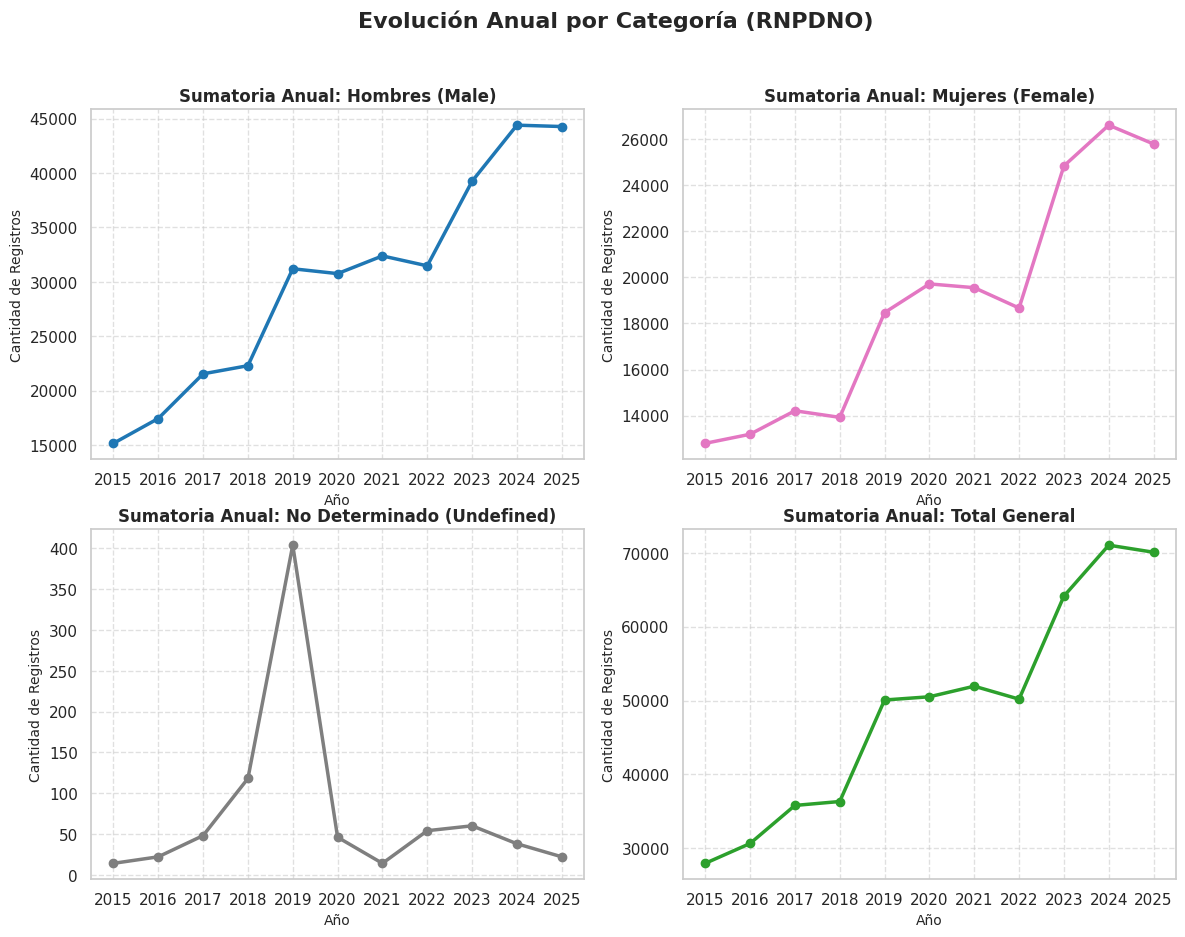

In [61]:
sns.set_theme(style='whitegrid')

# Creamos una figura de 2x2 para las 4 columnas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Evolución Anual por Categoría (RNPDNO)', fontsize=16, fontweight='bold'
)

# Configuración de cada columna
config = [
    ('male', 'Hombres (Male)', '#1f77b4'),
    ('female', 'Mujeres (Female)', '#e377c2'),
    ('undefined', 'No Determinado (Undefined)', '#7f7f7f'),
    ('total', 'Total General', '#2ca02c'),
]

for ax, (col, titulo, color) in zip(axes.flatten(), config):
  ax.plot(
      df_year['year'],
      df_year[col],
      marker='o',
      linewidth=2.5,
      color=color,
      label=titulo,
  )

  ax.set_title(f'Sumatoria Anual: {titulo}', fontsize=12, fontweight='bold')
  ax.set_xlabel('Año', fontsize=10)
  ax.set_ylabel('Cantidad de Registros', fontsize=10)
  ax.set_xticks(df_year['year'].unique())
  ax.grid(True, linestyle='--', alpha=0.6)

**Respuesta a la pregunta "¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal a partir de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?"**<br/>

Los resultados sugieren la existencia de un cambio en la tendencia de la serie temporal a partir de 2017. En la gráfica de registros totales se observa un incremento sostenido entre 2015 y 2017, seguido por una aceleración más marcada en los años posteriores, particularmente entre 2018 y 2019, cuando el número de registros aumenta de aproximadamente 36 mil a 50 mil casos.<br/>

Este comportamiento también se refleja en las categorías de hombres y mujeres, donde se aprecia un crecimiento más pronunciado después de 2017 en comparación con los años previos. Aunque la tendencia ya mostraba una trayectoria ascendente antes de 2017, los incrementos observados a partir de dicho año parecen indicar una posible modificación en la dinámica de registro y reporte de los casos.<br/>

La coincidencia temporal entre este cambio y la promulgación de la Ley General en Materia de Desaparición Forzada de Personas sugiere una posible relación. Sin embargo, a partir del análisis visual no es posible establecer una relación causal directa. <br/>

En conclusión, la evidencia gráfica indica un posible cambio de tendencia posterior a 2017, consistente con la hipótesis planteada, aunque se requiere un análisis estadístico formal para validar la magnitud y significancia de dicho cambio.
